# **Content-Based Recommendation System**

## This type of system suggests movies to a user by looking at the content (attributes) of the movie they like—such as the genre, director, and actors—and finding other movies that share those same characteristics.

# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.stem.porter import PorterStemmer

# **Load Dataset**

In [2]:
movies=pd.read_csv('/content/tmdb_5000_movies.csv.zip')
credits=pd.read_csv('/content/tmdb_5000_credits.csv.zip')
# For evaluation — keeping raw genre data before we transform it
movies_raw = pd.read_csv('/content/tmdb_5000_movies.csv.zip')
movies_raw['genres_list'] = movies_raw['genres'].apply(
    lambda obj: [i['name'] for i in ast.literal_eval(obj)]
)
genre_lookup = dict(zip(movies_raw['title'], movies_raw['genres_list']))

# **Phase 1: Data Preparation**

### Merging: You combined two separate files (movies and credits) into one DataFrame using the Title as a common key.

Selection: You narrowed down the data from 23 columns to the 7 essential ones: movie_id, title, overview, genres, keywords, cast, and crew.

Cleaning: You removed rows with null values and checked for duplicates to ensure the model wouldn't get confused by "garbage" data.

In [3]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [4]:
credits.head(1)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [5]:
# merging the data based on common attribute -> title
movies=movies.merge(credits,on='title')

In [6]:
movies.shape

(4809, 23)

In [7]:
credits.shape

(4803, 4)

In [8]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [9]:
movies.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   object 
 2   homepage              1713 non-null   object 
 3   id                    4809 non-null   int64  
 4   keywords              4809 non-null   object 
 5   original_language     4809 non-null   object 
 6   original_title        4809 non-null   object 
 7   overview              4806 non-null   object 
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   object 
 10  production_countries  4809 non-null   object 
 11  release_date          4808 non-null   object 
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   object 
 15  status               

In [10]:
movies=movies[["movie_id","keywords","genres","overview","title","cast","crew"]]

In [11]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4809 non-null   int64 
 1   keywords  4809 non-null   object
 2   genres    4809 non-null   object
 3   overview  4806 non-null   object
 4   title     4809 non-null   object
 5   cast      4809 non-null   object
 6   crew      4809 non-null   object
dtypes: int64(1), object(6)
memory usage: 263.1+ KB


In [12]:
# new data
movies.head()

,movie_id,keywords,genres,overview,title,cast,crew
0,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","In the 22nd century, a paraplegic Marine is di...",Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","Captain Barbossa, long believed to be dead, ha...",Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",A cryptic message from Bond’s past sends him o...,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",Following the death of District Attorney Harve...,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","John Carter is a war-weary, former military ca...",John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [13]:
movies.isnull().sum() / len(movies) * 100


,0
movie_id,0.000000
keywords,0.000000
genres,0.000000
overview,0.062383
title,0.000000
cast,0.000000
crew,0.000000


In [14]:
# checking for missing values
movies.isnull().sum()

,0
movie_id,0
keywords,0
genres,0
overview,3
title,0
cast,0
crew,0


In [15]:
# removing the missing values-dropna (from the original dataset)
movies.dropna(inplace=True)

In [16]:
movies.isnull().sum()

,0
movie_id,0
keywords,0
genres,0
overview,0
title,0
cast,0
crew,0


In [17]:
# checking for the duplicate values
movies.duplicated().sum()

np.int64(0)

# **Phase 2: Feature Engineering**

In [18]:
print(" Genre lookup ready. Sample:")
print("  Avatar →", genre_lookup.get('Avatar', 'not found'))
print("  The Dark Knight →", genre_lookup.get('The Dark Knight', 'not found'))


 Genre lookup ready. Sample:
  Avatar → ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
  The Dark Knight → ['Drama', 'Action', 'Crime', 'Thriller']


In [19]:
# .iloc[0]: This accesses the first row of the DataFrame using integer-location based indexing.

# genres: This accesses the genres column from that first row.
movies.iloc[0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [20]:
def convert(obj):
  list=[]

  for i in ast.literal_eval(obj):
    list.append(i['name'])
  return list

In [21]:
# convert str of list into python list so to avoid error-(TypeError: string indices must be integers, not 'str')
import ast
ast.literal_eval('[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]')

[{'id': 28, 'name': 'Action'},
 {'id': 12, 'name': 'Adventure'},
 {'id': 14, 'name': 'Fantasy'},
 {'id': 878, 'name': 'Science Fiction'}]

In [22]:
movies['genres']=movies['genres'].apply(convert)

In [23]:
movies.head(1)

,movie_id,keywords,genres,overview,title,cast,crew
0,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[Action, Adventure, Fantasy, Science Fiction]","In the 22nd century, a paraplegic Marine is di...",Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [24]:
movies.iloc[0].keywords

'[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]'

In [25]:
movies['keywords']=movies['keywords'].apply(convert)

In [26]:
movies.head(1)

,movie_id,keywords,genres,overview,title,cast,crew
0,19995,"[culture clash, future, space war, space colon...","[Action, Adventure, Fantasy, Science Fiction]","In the 22nd century, a paraplegic Marine is di...",Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [27]:
movies['cast'][0]

'[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 

In [28]:
# only need 3 actor and wante to access the only the actual name
def convert3(obj):
  list=[]
  counter=0
  for i in ast.literal_eval(obj):
    if counter != 3:
      list.append(i['name'])
      counter+=1
    else:
      break
  return list



In [29]:
movies['cast']=movies['cast'].apply(convert3)

In [30]:
movies.head(1)

,movie_id,keywords,genres,overview,title,cast,crew
0,19995,"[culture clash, future, space war, space colon...","[Action, Adventure, Fantasy, Science Fiction]","In the 22nd century, a paraplegic Marine is di...",Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [31]:
movies['crew'][0]

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

In [32]:
def fetch_director(obj):
  list=[]

  for i in ast.literal_eval(obj):
    if i['job'] == 'Director':
      list.append(i['name'])
      break
  return list


In [33]:
movies['crew']=movies['crew'].apply(fetch_director)

In [34]:
movies.head()

,movie_id,keywords,genres,overview,title,cast,crew
0,19995,"[culture clash, future, space war, space colon...","[Action, Adventure, Fantasy, Science Fiction]","In the 22nd century, a paraplegic Marine is di...",Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,"[ocean, drug abuse, exotic island, east india ...","[Adventure, Fantasy, Action]","Captain Barbossa, long believed to be dead, ha...",Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,"[spy, based on novel, secret agent, sequel, mi...","[Action, Adventure, Crime]",A cryptic message from Bond’s past sends him o...,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,"[dc comics, crime fighter, terrorist, secret i...","[Action, Crime, Drama, Thriller]",Following the death of District Attorney Harve...,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,"[based on novel, mars, medallion, space travel...","[Action, Adventure, Science Fiction]","John Carter is a war-weary, former military ca...",John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [35]:
# this is also a string
movies['overview'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [36]:
# to convert overview column into list so we can concatenate it with others columns
# x.split() breaks the string into a list of words using spaces as separators.

movies['overview']=movies['overview'].apply(lambda x : x.split())

In [37]:
movies.head()

,movie_id,keywords,genres,overview,title,cast,crew
0,19995,"[culture clash, future, space war, space colon...","[Action, Adventure, Fantasy, Science Fiction]","[In, the, 22nd, century,, a, paraplegic, Marin...",Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,"[ocean, drug abuse, exotic island, east india ...","[Adventure, Fantasy, Action]","[Captain, Barbossa,, long, believed, to, be, d...",Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,"[spy, based on novel, secret agent, sequel, mi...","[Action, Adventure, Crime]","[A, cryptic, message, from, Bond’s, past, send...",Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,"[dc comics, crime fighter, terrorist, secret i...","[Action, Crime, Drama, Thriller]","[Following, the, death, of, District, Attorney...",The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,"[based on novel, mars, medallion, space travel...","[Action, Adventure, Science Fiction]","[John, Carter, is, a, war-weary,, former, mili...",John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [38]:
# replace space between the names of one person to a full name without space
movies['genres']=movies['genres'].apply(lambda x :[i.replace(" ","" ) for i in x ])
movies['keywords']=movies['keywords'].apply(lambda x :[i.replace(" ","" ) for i in x ])
movies['cast']=movies['cast'].apply(lambda x :[i.replace(" ","" ) for i in x ])
movies['crew']=movies['crew'].apply(lambda x :[i.replace(" ","" ) for i in x ])

In [39]:
movies.head()

,movie_id,keywords,genres,overview,title,cast,crew
0,19995,"[cultureclash, future, spacewar, spacecolony, ...","[Action, Adventure, Fantasy, ScienceFiction]","[In, the, 22nd, century,, a, paraplegic, Marin...",Avatar,"[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron]
1,285,"[ocean, drugabuse, exoticisland, eastindiatrad...","[Adventure, Fantasy, Action]","[Captain, Barbossa,, long, believed, to, be, d...",Pirates of the Caribbean: At World's End,"[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski]
2,206647,"[spy, basedonnovel, secretagent, sequel, mi6, ...","[Action, Adventure, Crime]","[A, cryptic, message, from, Bond’s, past, send...",Spectre,"[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes]
3,49026,"[dccomics, crimefighter, terrorist, secretiden...","[Action, Crime, Drama, Thriller]","[Following, the, death, of, District, Attorney...",The Dark Knight Rises,"[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan]
4,49529,"[basedonnovel, mars, medallion, spacetravel, p...","[Action, Adventure, ScienceFiction]","[John, Carter, is, a, war-weary,, former, mili...",John Carter,"[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton]


In [40]:
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [41]:
movies.head(1)

,movie_id,keywords,genres,overview,title,cast,crew,tags
0,19995,"[cultureclash, future, spacewar, spacecolony, ...","[Action, Adventure, Fantasy, ScienceFiction]","[In, the, 22nd, century,, a, paraplegic, Marin...",Avatar,"[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron],"[In, the, 22nd, century,, a, paraplegic, Marin..."


In [42]:
# def create_weighted_tags(row):
#     return (
#         (row['genres'] * 3) + " " +
#         (row['keywords'] * 2) + " " +
#         (row['cast'] * 2) + " " +
#         (row['crew'] * 4) + " " +   # director heavy weight
#         (row['overview'] * 1)
#     )

# new_df['tags'] = new_df.apply(create_weighted_tags, axis=1)

In [43]:
movies.head(1)

,movie_id,keywords,genres,overview,title,cast,crew,tags
0,19995,"[cultureclash, future, spacewar, spacecolony, ...","[Action, Adventure, Fantasy, ScienceFiction]","[In, the, 22nd, century,, a, paraplegic, Marin...",Avatar,"[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron],"[In, the, 22nd, century,, a, paraplegic, Marin..."


In [44]:
movies['tags'][0]

['In',
 'the',
 '22nd',
 'century,',
 'a',
 'paraplegic',
 'Marine',
 'is',
 'dispatched',
 'to',
 'the',
 'moon',
 'Pandora',
 'on',
 'a',
 'unique',
 'mission,',
 'but',
 'becomes',
 'torn',
 'between',
 'following',
 'orders',
 'and',
 'protecting',
 'an',
 'alien',
 'civilization.',
 'Action',
 'Adventure',
 'Fantasy',
 'ScienceFiction',
 'cultureclash',
 'future',
 'spacewar',
 'spacecolony',
 'society',
 'spacetravel',
 'futuristic',
 'romance',
 'space',
 'alien',
 'tribe',
 'alienplanet',
 'cgi',
 'marine',
 'soldier',
 'battle',
 'loveaffair',
 'antiwar',
 'powerrelations',
 'mindandsoul',
 '3d',
 'SamWorthington',
 'ZoeSaldana',
 'SigourneyWeaver',
 'JamesCameron']

In [45]:
new_df=movies[['movie_id','title','tags']]

In [46]:
new_df

,movie_id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."
...,...,...,...
4804,9367,El Mariachi,"[El, Mariachi, just, wants, to, play, his, gui..."
4805,72766,Newlyweds,"[A, newlywed, couple's, honeymoon, is, upended..."
4806,231617,"Signed, Sealed, Delivered","[""Signed,, Sealed,, Delivered"", introduces, a,..."
4807,126186,Shanghai Calling,"[When, ambitious, New, York, attorney, Sam, is..."


In [47]:
# convert list of tags into strings
new_df['tags']=new_df['tags'].apply(lambda x :" ".join(x))

/tmp/ipykernel_8397/2770131026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']=new_df['tags'].apply(lambda x :" ".join(x))


In [48]:
new_df.head(1)

,movie_id,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."


In [49]:
new_df['tags'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. Action Adventure Fantasy ScienceFiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d SamWorthington ZoeSaldana SigourneyWeaver JamesCameron'

In [50]:
# recomend to convert all in lowercase
new_df['tags']=new_df['tags'].apply(lambda x:x.lower())

/tmp/ipykernel_8397/3648990224.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']=new_df['tags'].apply(lambda x:x.lower())


In [51]:
new_df.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


## **VECTORIZATIONS**


In [52]:
# text vectorization -convert the tags(text) into vectors
# Technique-bags of words => combine all the words (concatenate all tags) [large text]
# not focus on STOP WORDS(not have meaning just formatioin of the sentence) => will remove

## **Stemming**
Using PorterStemmer, you reduced words to their root form (e.g., "loved" and "loving" both became "love"). This ensures the system recognizes they are the same concept.

In [53]:
import nltk

In [54]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [55]:
def stem(text):
  y=[]

  for i in text.split():
    y.append(ps.stem(i))

  return " ".join(y)


In [56]:
ps.stem('danced')

'danc'

In [57]:
new_df['tags'][0]

'in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver jamescameron'

In [58]:
stem('in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver jamescameron action adventure fantasy sciencefiction')

'in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien tribe alienplanet cgi marin soldier battl loveaffair antiwar powerrel mindandsoul 3d samworthington zoesaldana sigourneyweav jamescameron action adventur fantasi sciencefict'

In [59]:
new_df['tags']=new_df['tags'].apply(stem)

/tmp/ipykernel_8397/3514595201.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']=new_df['tags'].apply(stem)


# **Vectorization (Bag of Words):**
You used CountVectorizer to turn text into math. It took the 5,000 most frequent words and turned every movie into a vector (a coordinate in 5,000-dimensional space).

In [60]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000,stop_words='english')
vectors = cv.fit_transform(new_df['tags']).toarray()

In [61]:
cv.fit_transform(new_df['tags']).toarray().shape

(4806, 5000)

In [62]:
vectors=cv.fit_transform(new_df['tags']).toarray()

In [63]:
vectors

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [64]:
vectors[0]

array([0, 0, 0, ..., 0, 0, 0])

In [65]:
cv.get_feature_names_out()

array(['000', '007', '10', ..., 'zone', 'zoo', 'zooeydeschanel'],
      dtype=object)

In [66]:
features=cv.get_feature_names_out()
print(features[:100])

['000' '007' '10' '100' '11' '12' '13' '14' '15' '16' '17' '17th' '18'
 '18th' '18thcenturi' '19' '1910' '1920' '1930' '1940' '1944' '1950'
 '1950s' '1960' '1960s' '1970' '1970s' '1971' '1974' '1976' '1980' '1985'
 '1990' '1999' '19th' '19thcenturi' '20' '200' '2003' '2009' '20th' '21st'
 '23' '24' '25' '30' '300' '3d' '40' '50' '500' '60' '70' '80' 'aaron'
 'aaroneckhart' 'abandon' 'abduct' 'abigailbreslin' 'abil' 'abl' 'aboard'
 'abov' 'abus' 'academ' 'academi' 'accept' 'access' 'accid' 'accident'
 'acclaim' 'accompani' 'accomplish' 'account' 'accus' 'ace' 'achiev'
 'acquaint' 'act' 'action' 'actionhero' 'activ' 'activist' 'activities'
 'actor' 'actress' 'actual' 'ad' 'adam' 'adamsandl' 'adamshankman' 'adapt'
 'add' 'addict' 'adjust' 'admir' 'admit' 'adolesc' 'adopt' 'ador']


In [67]:
# we have to calculate the distance between two vectors -- similarity using cosine_similarity not with eulid distance(tip to tip)
from sklearn.metrics.pairwise import cosine_similarity

In [68]:
similarity=cosine_similarity(vectors)

In [69]:
cosine_similarity(vectors).shape

(4806, 4806)

In [70]:
# it tells similarity of first movie with every other movies
similarity[1]

array([0.08346223, 1.        , 0.06063391, ..., 0.02378257, 0.        ,
       0.02615329])

In [71]:
# distance of first movie
similarity[0].shape

(4806,)

In [72]:
sorted(list(enumerate(similarity[0])),reverse=True,key=lambda x:x[1])[1:6]

[(1214, np.float64(0.28676966733820225)),
 (2405, np.float64(0.26901379342448517)),
 (3728, np.float64(0.2605130246476754)),
 (507, np.float64(0.255608593705383)),
 (539, np.float64(0.25038669783359574))]

In [73]:
from sklearn.neighbors import NearestNeighbors

# Initialize KNN model
knn = NearestNeighbors(metric='cosine', algorithm='brute')

# Fit on vectors
knn.fit(vectors)

NearestNeighbors(algorithm='brute', metric='cosine')

## **Recommendation**

In [74]:
# Genre Precision@5 function
# This is the KEY evaluation metric
def genre_precision_at_k(movie_title, similarity_matrix, df, genre_dict, k=5):
    """
    Measures: of the top-k recommended movies, what fraction
    share at least one genre with the query movie?

    Returns a score between 0.0 (no match) and 1.0 (all match).
    """
    # Get query movie's genres
    query_genres = set(genre_dict.get(movie_title, []))
    if not query_genres:
        return None  # skip movies with unknown genres

    # Get top-k recommendations (same logic as your recommend() function)
    idx = df[df['title'] == movie_title].index[0]
    distances = similarity_matrix[idx]
    top_k = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:k+1]

    # Count how many recommendations share a genre
    matches = 0
    for i, _ in top_k:
        rec_title = df.iloc[i]['title']
        rec_genres = set(genre_dict.get(rec_title, []))
        if query_genres & rec_genres:  # intersection = shared genre
            matches += 1
    return matches / k

In [75]:
def evaluate_recommender(similarity_matrix, df, genre_dict, test_movies, k=5):
    """
    Runs Genre Precision@K on a list of test movies and
    returns the average score (= your system's accuracy).
    """
    scores = []
    for movie in test_movies:
        if movie not in df['title'].values:
            continue
        score = genre_precision_at_k(movie, similarity_matrix, df, genre_dict, k)
        if score is not None:
            scores.append((movie, score))

    avg = np.mean([s for _, s in scores])
    return scores, avg

In [76]:
#Build TF-IDF recommender (for comparison)

# Your existing CountVectorizer similarity (already built above)
cv = CountVectorizer(max_features=5000, stop_words='english')
cv_vectors    = cv.fit_transform(new_df['tags']).toarray()
cv_similarity = cosine_similarity(cv_vectors)

# NEW: TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_vectors    = tfidf.fit_transform(new_df['tags']).toarray()
tfidf_similarity = cosine_similarity(tfidf_vectors)

print(" Both similarity matrices built:")
print(f"   CountVectorizer shape : {cv_similarity.shape}")
print(f"   TF-IDF shape          : {tfidf_similarity.shape}")


 Both similarity matrices built:
   CountVectorizer shape : (4806, 4806)
   TF-IDF shape          : (4806, 4806)


In [77]:
#  Run the evaluation on 20 test movies
# 20 well-known movies from the dataset (diverse genres)
test_movies = [
    'Avatar', 'The Dark Knight', 'Interstellar', 'Inception',
    'The Avengers', 'Toy Story', 'Titanic', 'The Godfather',
    'Forrest Gump', 'The Matrix', 'Jurassic Park', 'Finding Nemo',
    'Iron Man', 'The Lion King', 'Gladiator', 'The Silence of the Lambs',
    'Schindler\'s List', 'Pulp Fiction', 'Goodfellas', 'Fight Club'
]

In [78]:
# Evaluate CountVectorizer
cv_scores,    cv_avg    = evaluate_recommender(cv_similarity,    new_df, genre_lookup, test_movies)

# Evaluate TF-IDF
tfidf_scores, tfidf_avg = evaluate_recommender(tfidf_similarity, new_df, genre_lookup, test_movies)

print("\n" + "="*55)
print("      GENRE PRECISION@5 RESULTS")
print("="*55)
print(f"{'Movie':<30} {'CountVec':>10} {'TF-IDF':>10}")
print("-"*55)
cv_dict    = dict(cv_scores)
tfidf_dict = dict(tfidf_scores)

for movie in test_movies:
    cv_s    = cv_dict.get(movie, None)
    tfidf_s = tfidf_dict.get(movie, None)
    if cv_s is not None:
        bar_cv    = "★" * int(cv_s * 5)
        bar_tfidf = "★" * int(tfidf_s * 5)
        print(f"{movie:<30} {cv_s*100:>7.0f}%  {tfidf_s*100:>7.0f}%")

print("-"*55)
print(f"{'AVERAGE ACCURACY':<30} {cv_avg*100:>7.1f}%  {tfidf_avg*100:>7.1f}%")
print("="*55)
print(f"\n Your recommender correctly matches genre in")
print(f"   {cv_avg*100:.1f}% of recommendations on average.")



      GENRE PRECISION@5 RESULTS
Movie                            CountVec     TF-IDF
-------------------------------------------------------
Avatar                             100%      100%
The Dark Knight                    100%      100%
Interstellar                       100%      100%
Inception                          100%       60%
The Avengers                       100%      100%
Toy Story                          100%      100%
Titanic                             80%       80%
The Godfather                       80%       80%
Forrest Gump                        80%      100%
The Matrix                         100%      100%
Jurassic Park                       80%       60%
Finding Nemo                        80%       40%
Iron Man                           100%      100%
The Lion King                       80%       80%
Gladiator                          100%      100%
The Silence of the Lambs           100%      100%
Schindler's List                   100%      100%
Pulp Fic

In [79]:
#Show recommendations side by side (visual proof)


def show_recommendations_comparison(movie_title, cv_sim, tfidf_sim, df, genre_dict):
    """
    Prints a neat side-by-side table showing top-5 recommendations
    from both methods, with genre match indicators.
    """
    query_genres = set(genre_dict.get(movie_title, []))

    def get_top5(sim):
        idx = df[df['title'] == movie_title].index[0]
        top = sorted(list(enumerate(sim[idx])), reverse=True, key=lambda x: x[1])[1:6]
        return [(df.iloc[i]['title'], round(score, 3)) for i, score in top]

    cv_recs    = get_top5(cv_sim)
    tfidf_recs = get_top5(tfidf_sim)

    print(f"\n{'='*70}")
    print(f"  Movie: {movie_title}")
    print(f"  Genres: {', '.join(query_genres)}")
    print(f"{'='*70}")
    print(f"  {'CountVectorizer':<35} {'TF-IDF':<35}")
    print(f"  {'-'*33}  {'-'*33}")

    for (cv_t, cv_s), (tf_t, tf_s) in zip(cv_recs, tfidf_recs):
        cv_match = "✓" if set(genre_dict.get(cv_t,[])) & query_genres else "✗"
        tf_match = "✓" if set(genre_dict.get(tf_t,[])) & query_genres else "✗"
        print(f"  {cv_match} {cv_t:<33} {tf_match} {tf_t:<33}")

    print()

# Show comparisons for 5 representative movies
demo_movies = ['Avatar', 'The Dark Knight', 'Toy Story', 'Titanic', 'The Matrix']
for m in demo_movies:
    if m in new_df['title'].values:
        show_recommendations_comparison(m, cv_similarity, tfidf_similarity, new_df, genre_lookup)



  Movie: Avatar
  Genres: Fantasy, Adventure, Science Fiction, Action
  CountVectorizer                     TF-IDF                             
  ---------------------------------  ---------------------------------
  ✓ Aliens vs Predator: Requiem       ✓ Aliens                           
  ✓ Aliens                            ✓ Falcon Rising                    
  ✓ Falcon Rising                     ✓ Battle: Los Angeles              
  ✓ Independence Day                  ✓ Aliens vs Predator: Requiem      
  ✓ Titan A.E.                        ✓ Apollo 18                        


  Movie: The Dark Knight
  Genres: Thriller, Drama, Crime, Action
  CountVectorizer                     TF-IDF                             
  ---------------------------------  ---------------------------------
  ✓ The Dark Knight Rises             ✓ The Dark Knight Rises            
  ✓ Batman Begins                     ✓ Batman Returns                   
  ✓ Batman Returns                    ✓ Batman Begins

In [80]:
def recommend(movie):
  movie_index=new_df[new_df['title']==movie].index[0]
  distances=similarity[movie_index]
  movies_list=sorted(list(enumerate(distances)),reverse=True,key=lambda x:x[1])[1:6]


  for i in movies_list:
    print(new_df.iloc[i[0]].title)

In [81]:
recommend('Aliens')

Alien
Alien³
Meet Dave
Star Trek: Insurrection
Escape from Planet Earth


In [82]:
new_df

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a parapleg marin is dispa..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believ to be dead, ha c..."
2,206647,Spectre,a cryptic messag from bond’ past send him on a...
3,49026,The Dark Knight Rises,follow the death of district attorney harvey d...
4,49529,John Carter,"john carter is a war-weary, former militari ca..."
...,...,...,...
4804,9367,El Mariachi,el mariachi just want to play hi guitar and ca...
4805,72766,Newlyweds,a newlyw couple' honeymoon is upend by the arr...
4806,231617,"Signed, Sealed, Delivered","""signed, sealed, delivered"" introduc a dedic q..."
4807,126186,Shanghai Calling,when ambiti new york attorney sam is sent to s...


In [83]:
recommend('Avatar')

Aliens vs Predator: Requiem
Aliens
Falcon Rising
Independence Day
Titan A.E.


Text(0.5, 0.08, 'Tested on 19 movies  |  Top-5 recommendations each')

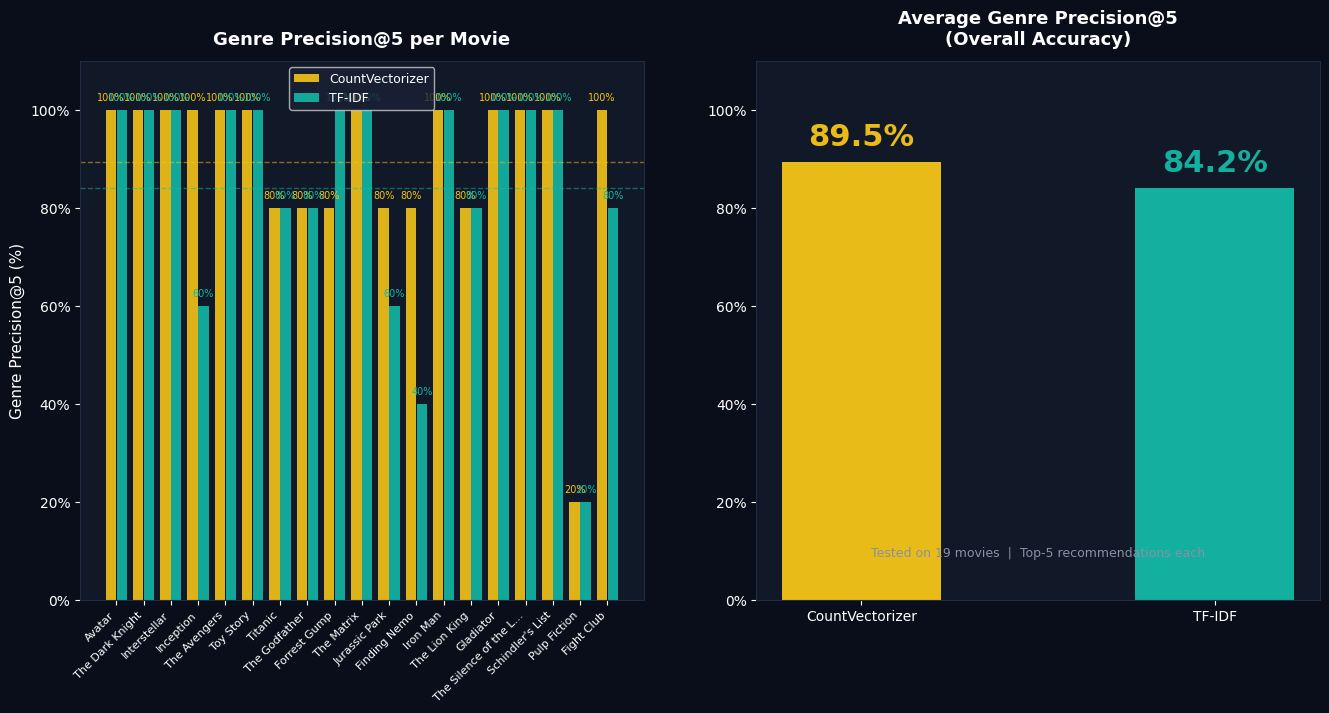

In [84]:
#Save chart as PNG (use in your presentation!)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0A0E1A')

movies_list = [m for m in test_movies if m in cv_dict]
cv_vals     = [cv_dict[m] * 100    for m in movies_list]
tfidf_vals  = [tfidf_dict.get(m, 0) * 100 for m in movies_list]
x           = np.arange(len(movies_list))
short_names = [m[:20] + '…' if len(m) > 20 else m for m in movies_list]

# ── Left plot: Side-by-side bar chart ────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#111827')
bars1 = ax1.bar(x - 0.2, cv_vals,    0.38, label='CountVectorizer', color='#F5C518', alpha=0.9)
bars2 = ax1.bar(x + 0.2, tfidf_vals, 0.38, label='TF-IDF',          color='#14B8A6', alpha=0.9)

ax1.set_xticks(x)
ax1.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8, color='white')
ax1.set_yticks(range(0, 101, 20))
ax1.set_yticklabels([f'{v}%' for v in range(0, 101, 20)], color='white')
ax1.set_ylabel('Genre Precision@5 (%)', color='white', fontsize=11)
ax1.set_title('Genre Precision@5 per Movie', color='white', fontsize=13, fontweight='bold', pad=12)
ax1.spines[:].set_color('#1E2D45')
ax1.tick_params(colors='white')
ax1.legend(facecolor='#1A2236', labelcolor='white', fontsize=9)
ax1.axhline(cv_avg * 100,    color='#F5C518', linestyle='--', linewidth=1, alpha=0.5)
ax1.axhline(tfidf_avg * 100, color='#14B8A6', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_ylim(0, 110)

# Add value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%',
             ha='center', va='bottom', fontsize=7, color='#F5C518')
for bar in bars2:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%',
             ha='center', va='bottom', fontsize=7, color='#14B8A6')

# ── Right plot: Average accuracy summary ─────────────────────
ax2 = axes[1]
ax2.set_facecolor('#111827')
ax2.spines[:].set_color('#1E2D45')

methods = ['CountVectorizer', 'TF-IDF']
avgs    = [cv_avg * 100, tfidf_avg * 100]
colors  = ['#F5C518', '#14B8A6']

bars = ax2.bar(methods, avgs, color=colors, width=0.45, alpha=0.95)
ax2.set_ylim(0, 110)
ax2.set_yticks(range(0, 101, 20))
ax2.set_yticklabels([f'{v}%' for v in range(0, 101, 20)], color='white')
ax2.set_title('Average Genre Precision@5\n(Overall Accuracy)', color='white',
              fontsize=13, fontweight='bold', pad=12)
ax2.tick_params(colors='white')

for bar, val in zip(bars, avgs):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=22, fontweight='bold',
             color=bar.get_facecolor())

ax2.text(0.5, 0.08,
         f'Tested on {len(movies_list)} movies  |  Top-5 recommendations each',
         transform=ax2.transAxes, ha='center', color='#8892A4', fontsize=9)


In [85]:
# Title & save
fig.suptitle('Movie Recommendation System — Evaluation Results',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('recommendation_evaluation.png', dpi=150, bbox_inches='tight',
            facecolor='#0A0E1A')
plt.show()
print("\n Chart saved as: recommendation_evaluation.png")

<Figure size 640x480 with 0 Axes>


 Chart saved as: recommendation_evaluation.png


In [86]:
# Quick sanity check: manual proof for 3 movies


def manual_proof(movie, cv_sim, df, genre_dict):
    query_genres = set(genre_dict.get(movie, []))
    idx = df[df['title'] == movie].index[0]
    top5 = sorted(list(enumerate(cv_sim[idx])), reverse=True, key=lambda x: x[1])[1:6]

    print(f"\n Query: {movie}")
    print(f"   Genres: {', '.join(query_genres)}")
    print(f"   {'#':<3} {'Recommended Movie':<30} {'Similarity':>10} {'Shared Genre':>15} {'Match':>6}")
    print(f"   {'-'*70}")
    correct = 0
    for rank, (i, score) in enumerate(top5, 1):
        title      = df.iloc[i]['title']
        rec_genres = set(genre_dict.get(title, []))
        shared     = query_genres & rec_genres
        match      = " YES" if shared else "NO"
        if shared: correct += 1
        shared_str = ', '.join(list(shared)[:2]) if shared else "—"
        print(f"   {rank:<3} {title:<30} {score:>10.4f} {shared_str:>15} {match:>6}")
    print(f"\n   ✓ {correct}/5 recommendations matched genre  →  Precision = {correct/5*100:.0f}%")

print("\n" + "="*75)
print("  MANUAL PROOF — Recommendation Quality Check")
print("="*75)
for movie in ['Avatar', 'The Dark Knight', 'Toy Story']:
    if movie in new_df['title'].values:
        manual_proof(movie, cv_similarity, new_df, genre_lookup)


  MANUAL PROOF — Recommendation Quality Check

 Query: Avatar
   Genres: Fantasy, Adventure, Science Fiction, Action
   #   Recommended Movie              Similarity    Shared Genre  Match
   ----------------------------------------------------------------------
   1   Aliens vs Predator: Requiem        0.2868 Fantasy, Science Fiction    YES
   2   Aliens                             0.2690 Science Fiction, Action    YES
   3   Falcon Rising                      0.2605 Adventure, Action    YES
   4   Independence Day                   0.2556 Adventure, Science Fiction    YES
   5   Titan A.E.                         0.2504 Adventure, Science Fiction    YES

   ✓ 5/5 recommendations matched genre  →  Precision = 100%

 Query: The Dark Knight
   Genres: Thriller, Drama, Crime, Action
   #   Recommended Movie              Similarity    Shared Genre  Match
   ----------------------------------------------------------------------
   1   The Dark Knight Rises              0.4226 Thriller, Dr

In [87]:
# SUMMARY PRINT

print("\n" + "="*55)
print("  FINAL SUMMARY FOR YOUR PRESENTATION")
print("="*55)
print(f"  Vectorizer        Avg Genre Precision@5")
print(f"  ─────────────     ─────────────────────")
print(f"  CountVectorizer   {cv_avg*100:.1f}%")
print(f"  TF-IDF            {tfidf_avg*100:.1f}%")
print(f"\n  Test set: {len(movies_list)} movies, Top-5 recommendations each")
print(f"  Metric: Genre Precision@K (standard recommender metric)")
print("="*55)


  FINAL SUMMARY FOR YOUR PRESENTATION
  Vectorizer        Avg Genre Precision@5
  ─────────────     ─────────────────────
  CountVectorizer   89.5%
  TF-IDF            84.2%

  Test set: 19 movies, Top-5 recommendations each
  Metric: Genre Precision@K (standard recommender metric)


In [95]:
recommend('Batman Begins')

The Dark Knight
Batman
Batman
The Dark Knight Rises
10th & Wolf


In [88]:
import pickle

In [89]:
pickle.dump(new_df,open('movies.pkl','wb'))

In [90]:
new_df

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a parapleg marin is dispa..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believ to be dead, ha c..."
2,206647,Spectre,a cryptic messag from bond’ past send him on a...
3,49026,The Dark Knight Rises,follow the death of district attorney harvey d...
4,49529,John Carter,"john carter is a war-weary, former militari ca..."
...,...,...,...
4804,9367,El Mariachi,el mariachi just want to play hi guitar and ca...
4805,72766,Newlyweds,a newlyw couple' honeymoon is upend by the arr...
4806,231617,"Signed, Sealed, Delivered","""signed, sealed, delivered"" introduc a dedic q..."
4807,126186,Shanghai Calling,when ambiti new york attorney sam is sent to s...


In [91]:
new_df['title'].values

array(['Avatar', "Pirates of the Caribbean: At World's End", 'Spectre',
       ..., 'Signed, Sealed, Delivered', 'Shanghai Calling',
       'My Date with Drew'], dtype=object)

In [92]:
movies_dict = new_df.to_dict(orient='list')

In [93]:
pickle.dump(new_df.to_dict(),open('movie_dict.pkl','wb'))

In [94]:
# new_df.to_dict()